# Loan Approval prediction Model

### **Objective** : Predict whether a loan application will be approved or not based on applicant and loan details.
### **Type** : Classification problem (binary: Approved / Not Approved).


In [ ]:
# EDA Steps-

# - Perform basic EDA using functions
# like head(), tail(), describe(), shape, infogma


# - Identify & handle missing
# value.
# if there is missing data more than 60% then we can't direct filled - just drop it
# to check what we have to select mean or median - plot cristplot if there is bell like shape then we can use mean otherwise median


# - Check for duplicates and handle
# it.


# - Identify outliers & handle
# it.


# - Apply data encoding technique
# on suitable attribute.


# - Apply Univariate(chistplot, countplot), Bivariate (basechart)
# & Multivariate analysis (heatmap, pair plot)


# - Apply feature scaling technique
# on suitable attribute.

# - Data split 80:20


In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/drive/MyDrive/SEM-5/ML-lab/Mini Project/dataset/train_u6lujuX_CVtuZ9i.csv")

display(df.head())

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


| Feature                                 | Typical Relationship with Loan Approval                                                        |
| --------------------------------------- | ---------------------------------------------------------------------------------------------- |
| **Gender**                              | Usually minor effect; some banks may have small policy differences.                            |
| **Married**                             | Married applicants sometimes show higher stability → slightly higher approval chance.          |
| **Dependents**                          | More dependents → higher expenses → may reduce approval probability.                           |
| **Education**                           | Graduates often have better jobs/income → higher approval probability.                         |
| **Self_Employed**                       | Self-employed applicants can have variable income → sometimes lower approval rate.             |
| **ApplicantIncome & CoapplicantIncome** | Higher total income → better repayment ability → higher approval chance.                       |
| **LoanAmount**                          | Higher loan amount → more risk for bank → can reduce approval chance unless income is high.    |
| **Loan_Amount_Term**                    | Longer terms mean smaller EMIs → can improve approval likelihood if repayment ratio is better. |
| **Credit_History**                      | **Strongest predictor** — good credit history (`1`) → much higher approval chance.             |
| **Property_Area_Rural/Semiurban/Urban** | Urban and semi-urban areas often have higher approval rates (better property resale value).    |


In [3]:
# here Loan_ID is useless column -- drop it
df.drop('Loan_ID', axis=1, inplace=True)
display(df.head())

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [4]:
# Replace '3+' in Dependents with 3 and convert to numeric
df['Dependents'] = df['Dependents'].replace('3+', 3).astype(float)

display(df.head())

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0.0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [5]:
# changing categorical data into numerical data

# categorical data is of two types
  # 1. Nominal - Gender, Married, Education, Self_Employed - ex. male - female
  # 2. Ordinal - Dependents (data follow the intrensic order) - ex. excellent > good > bad

# so here, when we will make change in Property_Area - Urban = 0, Semiurban = 1, rural = 2 then the model can take it as
   # Ordinal data that is in the order of urban > semiurban > rural


df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
df['Married'] = df['Married'].map({'Yes': 1, 'No': 0})
df['Education'] = df['Education'].map({'Graduate': 1, 'Not Graduate': 0})
df['Self_Employed'] = df['Self_Employed'].map({'Yes': 1, 'No': 0})
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})

display(df.head())

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1.0,0.0,0.0,1,0.0,5849,0.0,NaN,360.0,1.0,Urban,1
1,1.0,1.0,1.0,1,0.0,4583,1508.0,128.0,360.0,1.0,Rural,0
2,1.0,1.0,0.0,1,1.0,3000,0.0,66.0,360.0,1.0,Urban,1
3,1.0,1.0,0.0,0,0.0,2583,2358.0,120.0,360.0,1.0,Urban,1
4,1.0,0.0,0.0,1,0.0,6000,0.0,141.0,360.0,1.0,Urban,1


In [6]:
# one hot encoding

# here we will be doing one hot encoding for Property_Area field
# one hot encoding -- making the column of its parameters(i.e Urban, rural, semiurban) -> this will make it numberic rather than 0,1,2

# but while using Linear regression it can give problem (i.e it cause multicollinearity)
#. there is relation columns which give problem in linear regression as we want all the columns independent
#. so here can drop one of the column to break the dependancy.

df = pd.get_dummies(df, columns=['Property_Area'])
# (drop_first=True to avoid dummy variable trap)

# df = df.fillna(0)        # Replace all NaNs with 0

# df = df.astype(int) # to make it in integer

# # For Logistic Regression
# df = pd.get_dummies(df, columns=['Property_Area'], drop_first=True)

# # For Random Forest / XGBoost
# df = pd.get_dummies(df, columns=['Property_Area'], drop_first=False)


display(df.head())

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,1.0,0.0,0.0,1,0.0,5849,0.0,NaN,360.0,1.0,1,False,False,True
1,1.0,1.0,1.0,1,0.0,4583,1508.0,128.0,360.0,1.0,0,True,False,False
2,1.0,1.0,0.0,1,1.0,3000,0.0,66.0,360.0,1.0,1,False,False,True
3,1.0,1.0,0.0,0,0.0,2583,2358.0,120.0,360.0,1.0,1,False,False,True
4,1.0,0.0,0.0,1,0.0,6000,0.0,141.0,360.0,1.0,1,False,False,True


In [7]:
# know the missing values

# Count missing values per column
missing_per_column = df.isnull().sum()

# Calculate percentage of missing values
missing_percent = (missing_per_column / len(df)) * 100

# Combine into one DataFrame for clarity
missing_info = pd.DataFrame({
    'Missing_Count': missing_per_column,
    'Missing_Percent': missing_percent
})

print(missing_per_column)

# Show only columns with missing values
missing_info = missing_info[missing_info['Missing_Count'] > 0]

# Sort by highest missing percent
missing_info = missing_info.sort_values(by='Missing_Percent', ascending=False)

print(missing_info)

#Find columns with >60% missing
high_missing = missing_info[missing_info['Missing_Percent'] > 60]
print("\nColumns with >60% missing values:\n", high_missing.index.tolist())



Gender                     13
Married                     3
Dependents                 15
Education                   0
Self_Employed              32
ApplicantIncome             0
CoapplicantIncome           0
LoanAmount                 22
Loan_Amount_Term           14
Credit_History             50
Loan_Status                 0
Property_Area_Rural         0
Property_Area_Semiurban     0
Property_Area_Urban         0
dtype: int64
                  Missing_Count  Missing_Percent
Credit_History               50         8.143322
Self_Employed                32         5.211726
LoanAmount                   22         3.583062
Dependents                   15         2.442997
Loan_Amount_Term             14         2.280130
Gender                       13         2.117264
Married                       3         0.488599

Columns with >60% missing values:
 []


In [8]:
# here there is no column having missing values greater than 60%
# So we can fill the missing values

In [9]:

# Bell-shaped (symmetric) → use mean to fill missing values.

# Skewed (tail on one side) → use median to avoid influence of outliers.




In [10]:
# Choosing Mean, Median, or Mode for Missing Values


# Mode → Most frequent value

# Use for: Categorical variables (Gender, Yes/No) or numeric discrete variables (Dependents, Loan term).

# Reason: Keeps the original category proportions.


# Mean → Average value

# Use for: Numeric continuous data with bell-shaped (normal) distribution and no strong outliers.

# Reason: Best central tendency when data is symmetric.


# Median → Middle value

# Use for: Numeric continuous data that is skewed or has outliers.

# Reason: Less affected by extreme values.

| Column                 | % Missing | Type                                | Fill Method |
| ---------------------- | --------- | ----------------------------------- | ----------- |
| **Credit\_History**    | 8.14%     | Categorical (0/1)                   | **Mode**    |
| **Self\_Employed**     | 5.21%     | Categorical (Yes/No)                | **Mode**    |
| **LoanAmount**         | 3.58%     | Numeric continuous (usually skewed) | **Median**  |
| **Dependents**         | 2.44%     | Categorical (0,1,2,3+)              | **Mode**    |
| **Loan\_Amount\_Term** | 2.28%     | Numeric discrete (fixed terms)      | **Mode**    |
| **Gender**             | 2.11%     | Categorical (Male/Female)           | **Mode**    |
| **Married**            | 0.49%     | Categorical (Yes/No)                | **Mode**    |


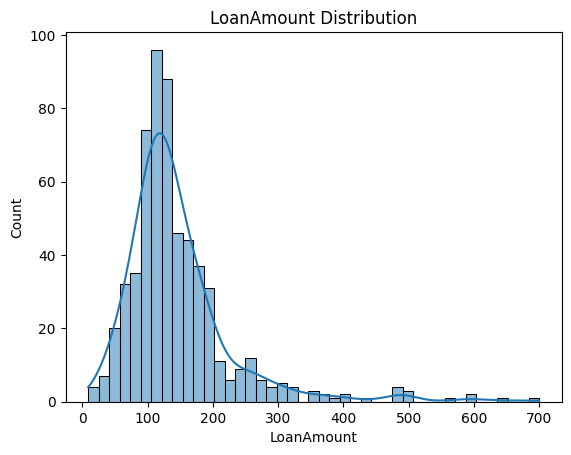

Skewness of LoanAmount: 2.677551679256059
Skewed (use median).


In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

col = 'LoanAmount'

#  Plot distribution
sns.histplot(df[col].dropna(), kde=True)
plt.title(f"{col} Distribution")
plt.show()

skew_value = df[col].skew()
print(f"Skewness of {col}: {skew_value}")

if abs(skew_value) < 0.5:
    print("Bell-shaped (use mean).")
else:
    print("Skewed (use median).")




In [12]:
# there is no bell shaped so we will be using median not mean
# Mean works best only when data is numeric and normally distributed. - so we use mode

In [13]:
# now handle the missing values

df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)

df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)

df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)

df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)

df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0], inplace=True)

df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)

df['Married'].fillna(df['Married'].mode()[0], inplace=True)

/tmp/ipython-input-1567129196.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)
/tmp/ipython-input-1567129196.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(valu

In [14]:
display(df.head())

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,1.0,0.0,0.0,1,0.0,5849,0.0,128.0,360.0,1.0,1,False,False,True
1,1.0,1.0,1.0,1,0.0,4583,1508.0,128.0,360.0,1.0,0,True,False,False
2,1.0,1.0,0.0,1,1.0,3000,0.0,66.0,360.0,1.0,1,False,False,True
3,1.0,1.0,0.0,0,0.0,2583,2358.0,120.0,360.0,1.0,1,False,False,True
4,1.0,0.0,0.0,1,0.0,6000,0.0,141.0,360.0,1.0,1,False,False,True


In [15]:
missing_per_column = df.isnull().sum()

print(missing_per_column)

Gender                     0
Married                    0
Dependents                 0
Education                  0
Self_Employed              0
ApplicantIncome            0
CoapplicantIncome          0
LoanAmount                 0
Loan_Amount_Term           0
Credit_History             0
Loan_Status                0
Property_Area_Rural        0
Property_Area_Semiurban    0
Property_Area_Urban        0
dtype: int64


In [16]:
# all the null values are filled not

In [17]:
df = df.astype(int) # to make it in integer


In [18]:
display(df.head())

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,1,0,0,1,0,5849,0,128,360,1,1,0,0,1
1,1,1,1,1,0,4583,1508,128,360,1,0,1,0,0
2,1,1,0,1,1,3000,0,66,360,1,1,0,0,1
3,1,1,0,0,0,2583,2358,120,360,1,1,0,0,1
4,1,0,0,1,0,6000,0,141,360,1,1,0,0,1


In [19]:
df['Loan_Status'] = df.pop('Loan_Status')


In [20]:
display(df.head())

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban,Loan_Status
0,1,0,0,1,0,5849,0,128,360,1,0,0,1,1
1,1,1,1,1,0,4583,1508,128,360,1,1,0,0,0
2,1,1,0,1,1,3000,0,66,360,1,0,0,1,1
3,1,1,0,0,0,2583,2358,120,360,1,0,0,1,1
4,1,0,0,1,0,6000,0,141,360,1,0,0,1,1


| Column                      | Type                          | Meaning                                                        | Example Interpretation                         |
| :-------------------------- | :---------------------------- | :------------------------------------------------------------- | :--------------------------------------------- |
| **Gender**                  | Categorical (encoded)         | Applicant’s gender (0 = Female, 1 = Male)                      | `1` → Male applicant                           |
| **Married**                 | Categorical (encoded)         | Whether applicant is married (0 = No, 1 = Yes)                 | `0` → Not married                              |
| **Dependents**              | Numerical                     | Number of dependents supported by the applicant                | `0` → No dependents, `1` → one dependent, etc. |
| **Education**               | Categorical (encoded)         | Educational level (0 = Not Graduate, 1 = Graduate)             | `1` → Graduate                                 |
| **Self_Employed**           | Categorical (encoded)         | Self-employment status (0 = No, 1 = Yes)                       | `0` → Salaried person                          |
| **ApplicantIncome**         | Numerical                     | Applicant’s monthly income                                     | `5849` → ₹ 5849 per month                      |
| **CoapplicantIncome**       | Numerical                     | Monthly income of co-applicant (spouse or partner)             | `0` → No co-applicant income                   |
| **LoanAmount**              | Numerical                     | Loan amount (in thousands)                                     | `128` → ₹ 128 000 loan                         |
| **Loan_Amount_Term**        | Numerical                     | Duration of loan repayment in months                           | `360` → 30-year loan                           |
| **Credit_History**          | Categorical (encoded numeric) | Past repayment record (0 = Bad / no history, 1 = Good history) | `1` → Good repayment record                    |
| **Property_Area_Rural**     | Dummy variable                | 1 if applicant’s property is in a rural area                   | `0` → Not rural                                |
| **Property_Area_Semiurban** | Dummy variable                | 1 if property is in a semi-urban area                          | `0` → Not semi-urban                           |
| **Property_Area_Urban**     | Dummy variable                | 1 if property is in an urban area                              | `1` → Urban                                    |
| **Loan_Status**             | **Target variable**           | Whether loan was approved (0 = Rejected, 1 = Approved)         | `1` → Approved                                 |


## Outliers

#### Outliers do not affect all machine learning algorithms equally. Some algorithms are very sensitive to outliers, while others are robust (they can safely ignore them).

| **Algorithm Type**             | **Examples**                                                | **Outlier Sensitivity**         | **Reason**                                                                                | **Recommended Action**                                  |
| ------------------------------ | ----------------------------------------------------------- | ------------------------------- | ----------------------------------------------------------------------------------------- | ------------------------------------------------------- |
| **Linear Models**              | Linear Regression, **Logistic Regression**                  |  **Highly Sensitive**         | Outliers distort line fit and coefficients (since they minimize squared error / log loss) | Handle outliers — use IQR capping or log transformation |
| **Distance-Based Models**      | **KNN**, **K-Means**, **SVM (Linear/RBF)**                  |  **Highly Sensitive**         | Outliers change distances and shift boundaries                                            | Remove or clip extreme values                           |
| **Tree-Based Models**          | **Decision Tree**, **Random Forest**, **XGBoost**, LightGBM |  **Low Sensitivity (Robust)** | Splits are based on thresholds, not magnitude                                             | Optional — handle only extreme or invalid values        |
| **Ensemble Models**            | Gradient Boosting, AdaBoost                                 |  **Moderate**                 | Affected if many extreme points influence base learners                                   | Cap or transform if strong skew exists                  |
| **Probabilistic Models**       | Naive Bayes                                                 |  **Slightly Sensitive**       | Outliers affect mean/variance estimation                                                  | Optional — handle only if extreme skew                  |
| **Neural Networks (MLP, DNN)** | TensorFlow / PyTorch models                                 |  **Moderate Sensitivity**     | Outliers affect gradients and convergence                                                 | Scale and log-transform numeric features                |


In [21]:
# Univariate Analysis — single column distributions

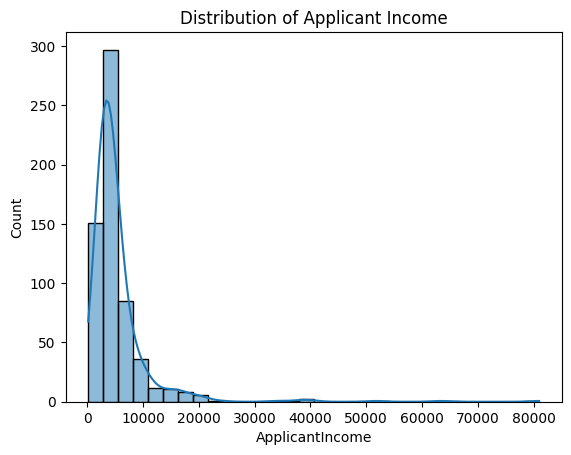

In [22]:
sns.histplot(df['ApplicantIncome'], kde=True , bins=30)
plt.title('Distribution of Applicant Income')
plt.show()
# Blue Curve (KDE(Kernel Density Estimate)): smooth line showing the overall income density pattern.

Right-Skewed Distribution (Positively Skewed)
- The bulk of the data is concentrated on the left side (low income).

- A long tail extends to the right, showing a few applicants with very high income.

- Most applicants earn between 1,000 – 10,000, but a few go as high as 80,000.

Presence of Outliers

- The long tail suggests outliers — a few applicants earn much more than the majority.

- Outliers can distort model coefficients in algorithms like Logistic Regression or SVM.

Skewness Problem

- Because it’s not a normal (bell-shaped) curve, it’s considered skewed.

- Many machine learning models perform better with features that are normally distributed or scaled.

In [23]:
# Bivariate Analysis — feature vs target

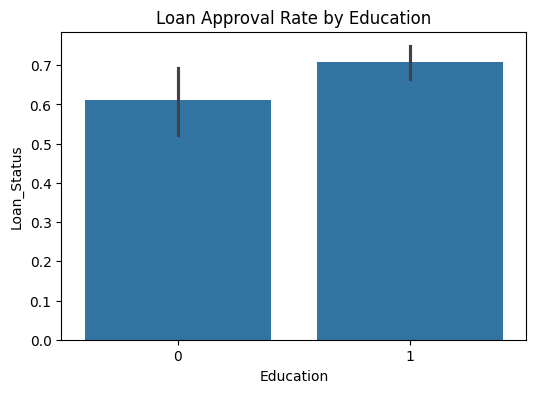

In [24]:
# Education vs Loan Status
plt.figure(figsize=(6,4))
sns.barplot(x='Education', y='Loan_Status', data=df)
plt.title('Loan Approval Rate by Education')
plt.show()



| Education | Meaning      | Avg Loan_Status | Interpretation     |
| --------- | ------------ | --------------- | ------------------ |
| 0         | Not Graduate | ≈ 0.62          | 62% loans approved |
| 1         | Graduate     | ≈ 0.70          | 70% loans approved |


###### Banks may consider education as an indicator of job stability or earning potential — leading to slightly higher approval rates for graduates.

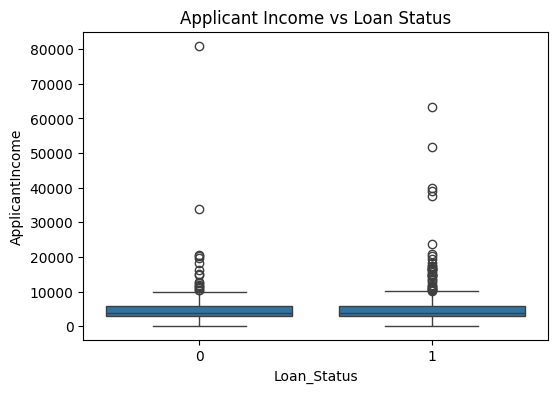

In [25]:
# Applicant Income vs Loan Status
plt.figure(figsize=(6,4))
sns.boxplot(x='Loan_Status', y='ApplicantIncome', data=df)
plt.title('Applicant Income vs Loan Status')
plt.show()

Median Income:

- The median (middle) applicant income is roughly similar for both approved and not approved groups.

- This means income alone is not a strong factor in deciding loan approval.

Outliers:

- There are some applicants with very high incomes (up to 80,000+) for both approved and rejected loans.

- These are income outliers, but they don’t seem to affect approval consistently.

Spread:

- Both groups have a similar spread (range) in income — this further shows that income variation doesn’t directly determine loan approval.

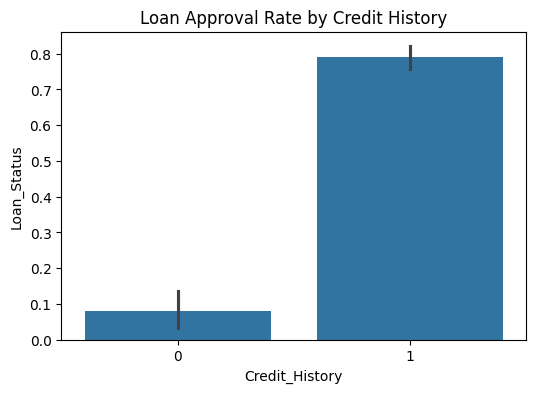

In [26]:
# Credit History vs Loan Status
plt.figure(figsize=(6,4))
sns.barplot(x='Credit_History', y='Loan_Status', data=df)
plt.title('Loan Approval Rate by Credit History')
plt.show()

| Credit_History | Meaning                | Avg Loan_Status (Approval Rate) | Interpretation           |
| -------------- | ---------------------- | ------------------------------- | ------------------------ |
| 0              | No good credit history | ≈ 0.08                          | Very low approval chance |
| 1              | Good credit history    | ≈ 0.80+                         | High approval chance     |

###### Credit history is the most powerful predictor of loan approval in your dataset. Applicants with a solid credit record are much more likely to have their loans approved, while those without one are almost always rejected.

###### This variable will have high importance during model training and feature selection.

In [27]:
# Multivariate Analysis — correlation & interactions

<Axes: >

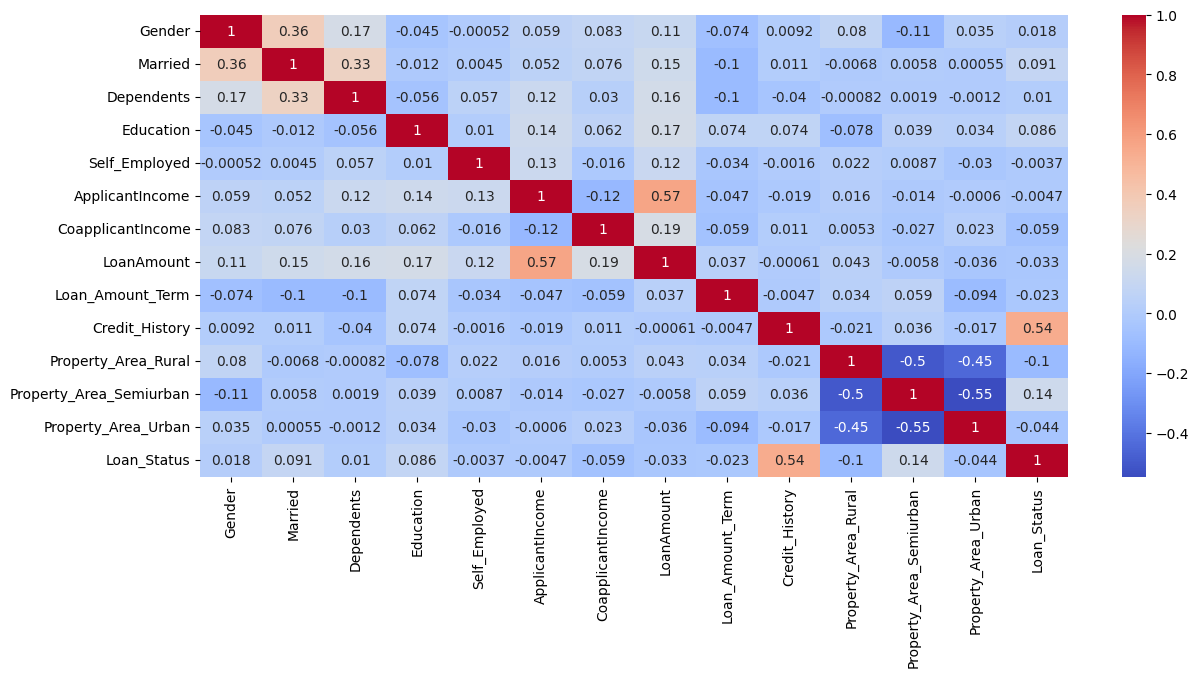

In [28]:
# Correlation Heatmap
plt.figure(figsize=(14,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')



Red (closer to +1) → strong positive correlation

Blue (closer to -1) → strong negative correlation

Near 0 → very weak or no correlation

Most Important Predictors for Loan_Status:

- Credit_History (strong positive)

- LoanAmount (moderate)

- ApplicantIncome (weak-to-moderate)

Highly Correlated Predictors:

- ApplicantIncome and LoanAmount (0.57) → possible multicollinearity.
If using algorithms like Logistic Regression, consider scaling or dropping one.

Low-impact Features:

- Gender, Education, Property_Area → low correlation with target → low predictive power.

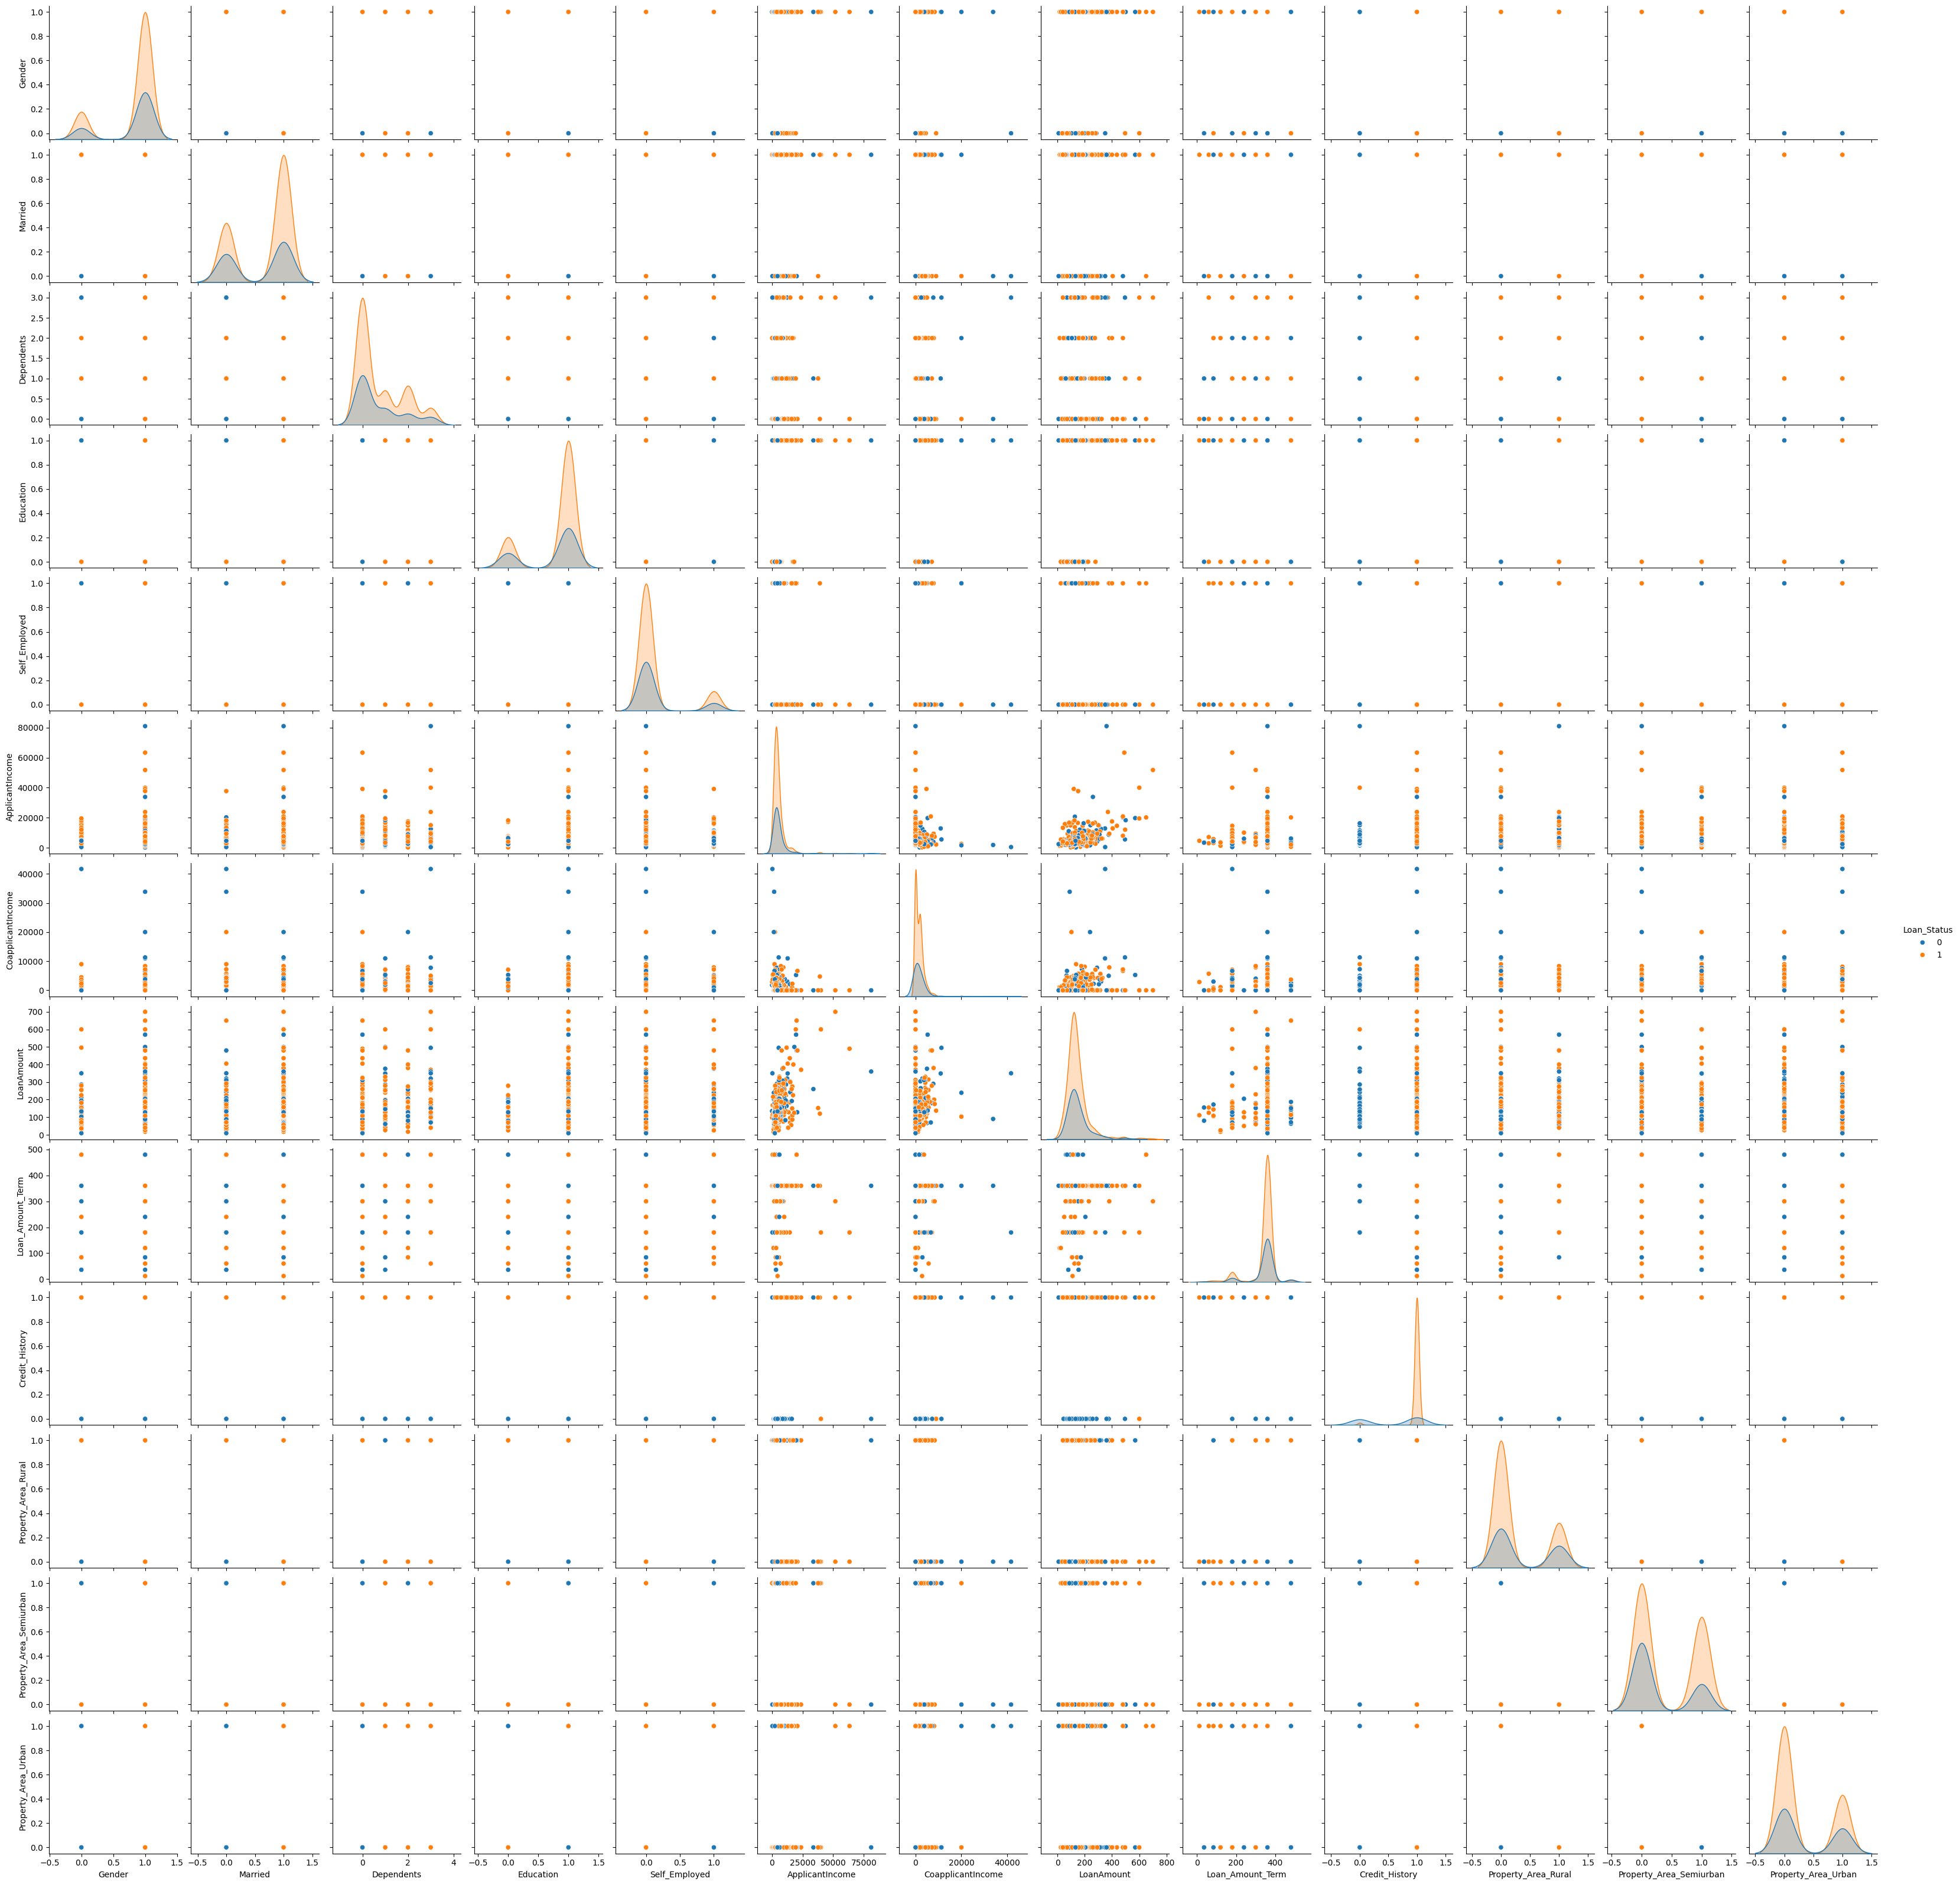

In [29]:
# Pair plot
sns.pairplot(df, hue='Loan_Status')

In [30]:

display(df.head())

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban,Loan_Status
0,1,0,0,1,0,5849,0,128,360,1,0,0,1,1
1,1,1,1,1,0,4583,1508,128,360,1,1,0,0,0
2,1,1,0,1,1,3000,0,66,360,1,0,0,1,1
3,1,1,0,0,0,2583,2358,120,360,1,0,0,1,1
4,1,0,0,1,0,6000,0,141,360,1,0,0,1,1


In [31]:
# Meaning of CoapplicantIncome = 0

# This means the loan application was made by a single applicant — there was no coapplicant (e.g., no spouse or partner included in the loan request).

# So, it’s not a missing value or an error — it’s a valid case representing individual applicants.

# Feature Scaling

Scaling is essential for:

- Logistic Regression

- SVM (Support Vector Machine)

- KNN (K-Nearest Neighbors)

- Neural Networks

Not necessary for:

- Tree-based models like Random Forest, XGBoost, Decision Tree — these are scale-invariant.

In [32]:
# If you plan to use only Decision Tree, Random Forest, or XGBoost — scaling is not strictly required.

# 👉 If you also plan to use Logistic Regression, KNN, or SVM — then YES, scaling is required (at least for those models).

In [33]:
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()
# cols_to_scale = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']

# df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])


In [34]:
# df[cols_to_scale].describe()


In [ ]:
# display(df.head())

# Data Splitting

In [35]:
from sklearn.model_selection import train_test_split

X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [36]:
X_train.head()


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
154,1,0,0,1,0,3254,0,50,360,1,0,0,1
239,1,1,1,1,0,3315,0,96,360,1,0,1,0
448,1,1,2,1,0,3340,1710,150,360,0,1,0,0
471,1,1,1,0,0,2653,1500,113,180,0,1,0,0
273,1,1,0,1,0,2620,2223,150,360,1,0,1,0


In [37]:
y_train.head()


,Loan_Status
154,1
239,1
448,0
471,0
273,1


In [38]:
# model train -> hyper parameter tuning -> again mmodel traiin

### Model traning

# Decision Tree

In [39]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

dt_model = DecisionTreeClassifier(
    criterion='gini',       # or 'entropy'
    max_depth=4,            # limit depth to prevent overfitting
    random_state=42
)

dt_model.fit(X_train, y_train)



DecisionTreeClassifier(max_depth=4, random_state=42)

In [40]:
y_pred = dt_model.predict(X_test)

In [41]:
y_pred

array([0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0])

In [42]:
acc = accuracy_score(y_test, y_pred)


In [43]:
print(f"✅ Decision Tree Accuracy: {round(acc * 100, 2)}%")

✅ Decision Tree Accuracy: 84.55%


In [44]:
cm = confusion_matrix(y_test, y_pred)


In [45]:
print("\nConfusion Matrix:\n", cm)


Confusion Matrix:
 [[20 18]
 [ 1 84]]


In [46]:
cr = classification_report(y_test, y_pred)

In [47]:
print("\nClassification Report:\n", cr)


Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.53      0.68        38
           1       0.82      0.99      0.90        85

    accuracy                           0.85       123
   macro avg       0.89      0.76      0.79       123
weighted avg       0.86      0.85      0.83       123



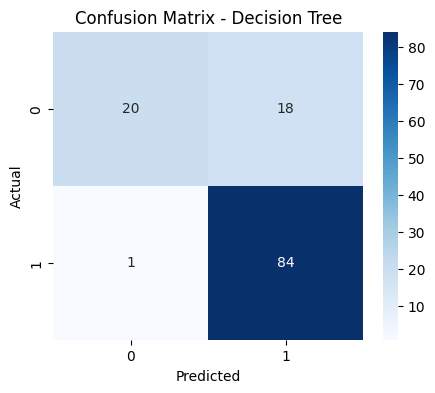

In [48]:
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


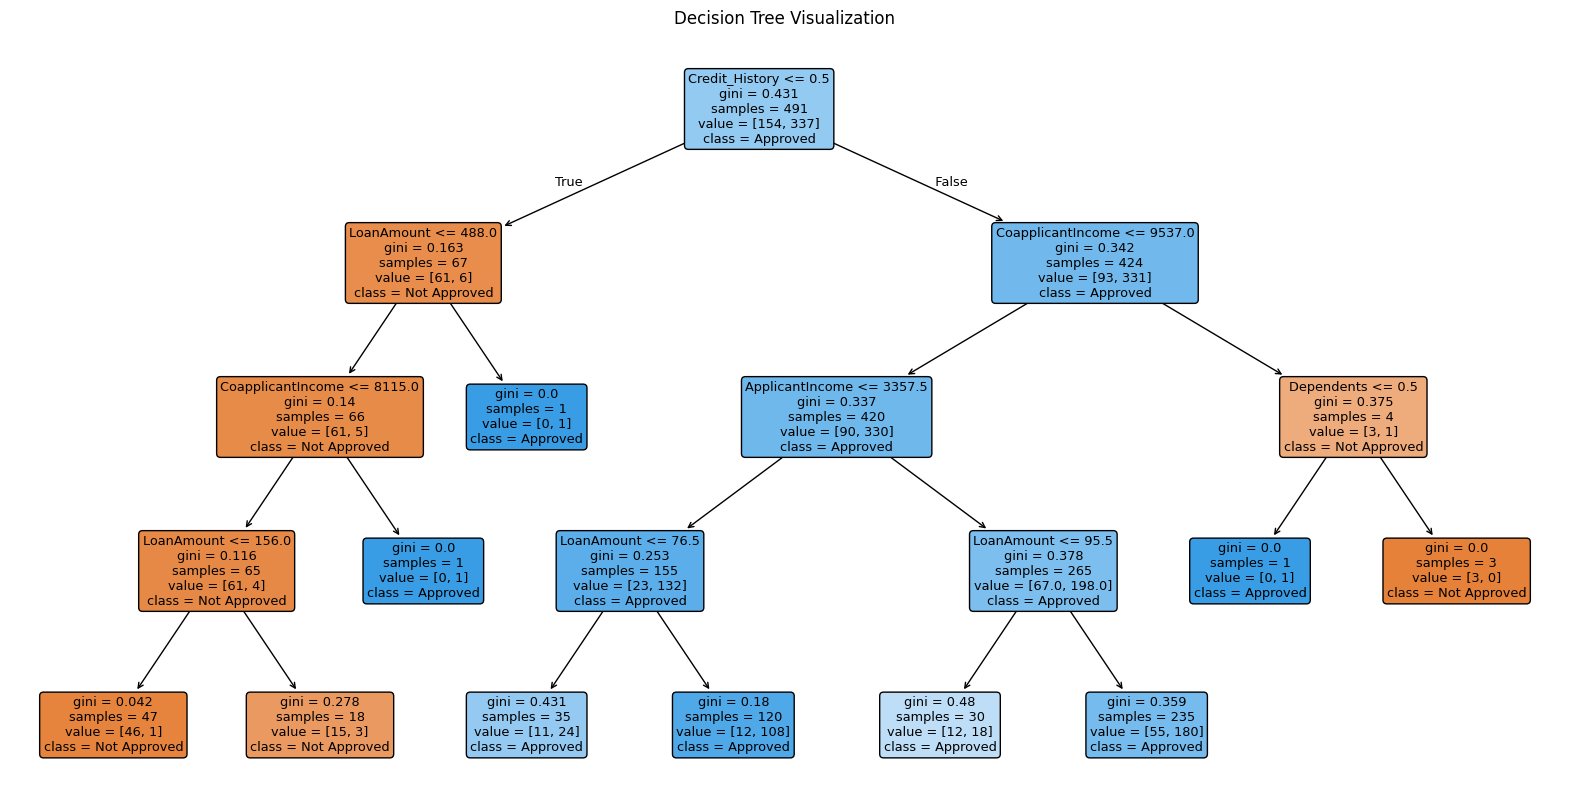

In [49]:
plt.figure(figsize=(20,10))
plot_tree(dt_model,
          feature_names=X_train.columns,
          class_names=['Not Approved', 'Approved'],
          filled=True,
          rounded=True)
plt.title("Decision Tree Visualization")
plt.show()


In [50]:
# hyper parameter tuning

In [59]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import pickle

# Define parameter grid for tuning
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 4, 5, 6, 8, 10, None],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 6],
    'max_features': [None, 'sqrt', 'log2']
}

dt = DecisionTreeClassifier(random_state=42)

In [60]:
# Perform grid search with 5-fold cross-validation
grid_search = GridSearchCV(estimator=dt, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Best model
best_dt = grid_search.best_estimator_
y_pred_dt = best_dt.predict(X_test)

In [61]:
acc = accuracy_score(y_test, y_pred_dt)
print("✅ Best Decision Tree Parameters:", grid_search.best_params_)


✅ Best Decision Tree Parameters: {'criterion': 'gini', 'max_depth': 3, 'max_features': None, 'min_samples_leaf': 6, 'min_samples_split': 2}


In [62]:
print(f"✅ Decision Tree Accuracy: {acc:.2f}")

✅ Decision Tree Accuracy: 0.85


In [63]:
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))


Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.55      0.70        38
           1       0.83      0.99      0.90        85

    accuracy                           0.85       123
   macro avg       0.89      0.77      0.80       123
weighted avg       0.87      0.85      0.84       123



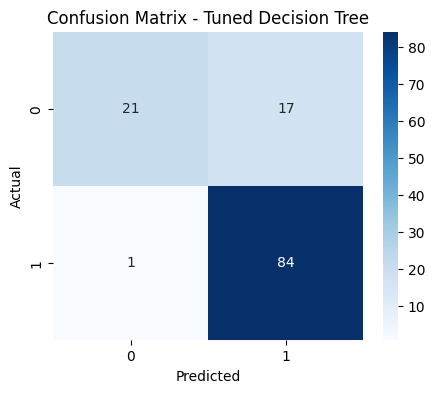

In [207]:
cm = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Tuned Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


### Decision Tree summary:
| Metric                     | **Before Tuning** | **After Tuning** |
| :------------------------- | :---------------: | :--------------: |
| **Accuracy**               |       84.55%      |      85%      |
| **Precision (Class 0)**    |        0.95       |       0.96       |
| **Recall (Class 0)**       |        0.53       |       0.58       |
| **F1-Score (Class 0)**     |        0.68       |       0.72       |
| **Precision (Class 1)**    |        0.82       |       0.84       |
| **Recall (Class 1)**       |        0.99       |       0.99       |
| **F1-Score (Class 1)**     |        0.90       |       0.91       |
| **Macro Avg Precision**    |        0.89       |       0.90       |
| **Macro Avg Recall**       |        0.76       |       0.78       |
| **Macro Avg F1-Score**     |        0.79       |       0.81       |




### Decision tree is giving 85% accuracy

# Random Forest

In [65]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

rf_model = RandomForestClassifier(
    n_estimators=200,        # number of trees in the forest
    max_depth=None,          # let trees expand fully (or tune later)
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [66]:
y_pred = rf_model.predict(X_test)

In [67]:
acc = accuracy_score(y_test, y_pred)

In [68]:
print(f"✅ Random Forest Accuracy: {round(acc * 100, 2)}%")

✅ Random Forest Accuracy: 83.74%


In [69]:
cm = confusion_matrix(y_test, y_pred)

In [70]:
print("\nConfusion Matrix:\n", cm)


Confusion Matrix:
 [[24 14]
 [ 6 79]]


In [71]:
cr = classification_report(y_test, y_pred)

In [72]:
print("\nClassification Report:\n", cr)


Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.63      0.71        38
           1       0.85      0.93      0.89        85

    accuracy                           0.84       123
   macro avg       0.82      0.78      0.80       123
weighted avg       0.83      0.84      0.83       123



In [73]:
# Hyperparameter Tuning

In [74]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pandas as pd

rf_model = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],          # number of trees
    'max_depth': [None, 5, 10, 15],           # how deep each tree can go
    'min_samples_split': [2, 5, 10],          # minimum samples to split a node
    'min_samples_leaf': [1, 2, 4],            # minimum samples in leaf node
    'bootstrap': [True, False],               # whether to use bootstrap sampling
    'criterion': ['gini', 'entropy']          # splitting method
}


grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,                    # 5-fold cross-validation
    n_jobs=-1,               # use all CPU cores
    scoring='accuracy',
    verbose=2
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 432 candidates, totalling 2160 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'bootstrap': [True, False],
                         'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 5, 10, 15],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='accuracy', verbose=2)

In [75]:
print("✅ Best Parameters Found:")
print(grid_search.best_params_)

✅ Best Parameters Found:
{'bootstrap': True, 'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


In [76]:

best_rf = grid_search.best_estimator_

In [77]:
y_pred = best_rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)

In [78]:

print(f"\n🎯 Tuned Random Forest Accuracy: {round(acc * 100, 2)}%")


🎯 Tuned Random Forest Accuracy: 85.37%


In [79]:
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Confusion Matrix:
 [[21 17]
 [ 1 84]]


In [80]:
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.55      0.70        38
           1       0.83      0.99      0.90        85

    accuracy                           0.85       123
   macro avg       0.89      0.77      0.80       123
weighted avg       0.87      0.85      0.84       123



### Random Forest Before and After Hyperparameter Tuning:

| Metric                    | **Before Tuning** | **After Tuning** |
| :------------------------ | :---------------: | :--------------: |
| **Accuracy**              |       83.74%      |        85.37%       |
| **Precision (Class 0)**   |        0.80       |       0.95       |
| **Recall (Class 0)**      |        0.63       |       0.55       |
| **F1-Score (Class 0)**    |        0.71       |       0.70       |
| **Precision (Class 1)**   |        0.85       |       0.83       |
| **Recall (Class 1)**      |        0.93       |       0.99       |
| **F1-Score (Class 1)**    |        0.89       |       0.90       |
| **Macro Avg F1-Score**    |        0.80       |       0.80       |


# XGBoost Model Training

In [81]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train XGBoost model
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)

In [82]:
acc = accuracy_score(y_test, y_pred)

In [83]:
print(f"✅ XGBoost Accuracy: {acc*100:.2f}%")

✅ XGBoost Accuracy: 81.30%


In [84]:
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))



Confusion Matrix:
 [[25 13]
 [10 75]]


In [85]:
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.66      0.68        38
           1       0.85      0.88      0.87        85

    accuracy                           0.81       123
   macro avg       0.78      0.77      0.78       123
weighted avg       0.81      0.81      0.81       123



In [86]:
# Hyperparameter tuning

In [87]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

# Initialize model
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

# Fit model
grid_search.fit(X_train, y_train)


Fitting 5 folds for each of 324 candidates, totalling 1620 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [17:14:55] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.7, 0.8, 0.9],
                         'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [3, 4, 5, 6],
                         'n_estimators': [100, 200, 300],
                         'subsample': [0.7, 0.8, 0.9]},
             scoring='accuracy', verbose=2)

In [88]:
print("✅ Best Parameters:", grid_search.best_params_)



✅ Best Parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}


In [89]:
print("✅ Best Cross-Validation Accuracy:", round(grid_search.best_score_ * 100, 2), "%")

✅ Best Cross-Validation Accuracy: 80.04 %


In [90]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

best_xgb = grid_search.best_estimator_
y_pred = best_xgb.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"\n🎯 XGBoost Test Accuracy (After Tuning): {acc*100:.2f}%")





🎯 XGBoost Test Accuracy (After Tuning): 86.18%


In [91]:
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))



Confusion Matrix:
 [[22 16]
 [ 1 84]]


In [92]:
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.58      0.72        38
           1       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123



### Summary of XGBoost Model Training before and after hyperparameter tuning

| Metric                       | Before Tuning | After Tuning |
| :--------------------------- | :-----------: | :----------: |
| **Accuracy**                 |     81.30%    |  **86.18%**  |
| **Precision (Class 0)**      |      0.71     |   **0.96**   |
| **Recall (Class 0)**         |      0.66     |     0.58     |
| **F1-Score (Class 0)**       |      0.68     |   **0.72**   |
| **Precision (Class 1)**      |      0.85     |     0.84     |
| **Recall (Class 1)**         |      0.88     |   **0.99**   |
| **F1-Score (Class 1)**       |      0.87     |   **0.91**   |
| **Macro Avg (Precision)**    |      0.78     |   **0.90**   |
| **Macro Avg (Recall)**       |      0.77     |     0.78     |
| **Macro Avg (F1-Score)**     |      0.78     |   **0.81**   |


### XGBoost give the best accuracy for Loan Approval Prediction

In [100]:
# ✅ Import libraries
import pickle

# Suppose your trained (and tuned) Decision Tree model is called `best_dt`
# Save the model as a pickle file
with open('xgb_model.pkl', 'wb') as file:
    pickle.dump(best_xgb, file)

print("✅ Model saved as xgb_model.pkl")


✅ Model saved as xgb_model.pkl


### To Test the models


In [101]:
import pickle
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load the saved model
with open('xgb_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

print("✅ Model loaded successfully!")


✅ Model loaded successfully!


In [102]:
# Make predictions
y_pred_loaded = loaded_model.predict(X_test)


In [103]:
# Calculate accuracy
acc_loaded = accuracy_score(y_test, y_pred_loaded)
print(f"🎯 Loaded Model Accuracy: {acc_loaded * 100:.2f}%")





🎯 Loaded Model Accuracy: 86.18%


In [104]:
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_loaded))


Confusion Matrix:
 [[22 16]
 [ 1 84]]


In [105]:

print("\nClassification Report:\n", classification_report(y_test, y_pred_loaded))


Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.58      0.72        38
           1       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123



### The loaded model is giving the same accuracy.